# 🎬 Обучение Трансформера для классификации жанров фильмов

### 🎯 Цель проекта:
Создать модель, которая по текстовому описанию сюжета сможет автоматически определить его основной жанр.

---

## 1. Подготовка окружения и установка библиотек

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

c:\Users\rakhm\anaconda3\envs\ml-iris\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используемое устройство: cpu


## 2. Загрузка и Исследовательский анализ данных (EDA)

Используем датасет **jquigl/imdb-genres**, который содержит описания фильмов и их основные жанры.

In [ ]:
dataset = load_dataset("jquigl/imdb-genres")

train_df = pd.DataFrame(dataset['train'])

print(f"Общее количество примеров: {len(train_df)}")
print(f"Уникальные жанры: {train_df['genre'].unique()}")
train_df.head()

Общее количество примеров: 238256
Уникальные жанры: ['Fantasy' 'Romance' 'Thriller' 'Biography' 'Horror' 'Action' 'Crime'
 'Animation' 'Adventure' 'Mystery' 'War' 'Family' 'History' 'Scifi'
 'Film-noir' 'Sports']


,movie title - year,genre,expanded-genres,rating,description
0,Flaming Ears - 1992,Fantasy,"Fantasy, Sci-Fi",6.0,Flaming Ears is a pop sci-fi lesbian fantasy f...
1,Jeg elsker dig - 1957,Romance,"Comedy, Drama, Romance",5.8,Six people - three couples - meet at random at...
2,Povjerenje - 2021,Thriller,Thriller,NaN,"In a small unnamed town, in year 2025, Krsto w..."
3,Gulliver Returns - 2021,Fantasy,"Animation, Adventure, Family",4.4,The legendary Gulliver returns to the Kingdom ...
4,Prithvi Vallabh - 1924,Biography,"Biography, Drama, Romance",NaN,"Seminal silent historical film, the story feat..."


### 📊 Визуализация распределения жанров
Посмотрим, какие жанры встречаются чаще всего.

C:\Users\rakhm\AppData\Local\Temp\ipykernel_23908\2538276107.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='genre', data=train_df, order=train_df['genre'].value_counts().index, palette='viridis')


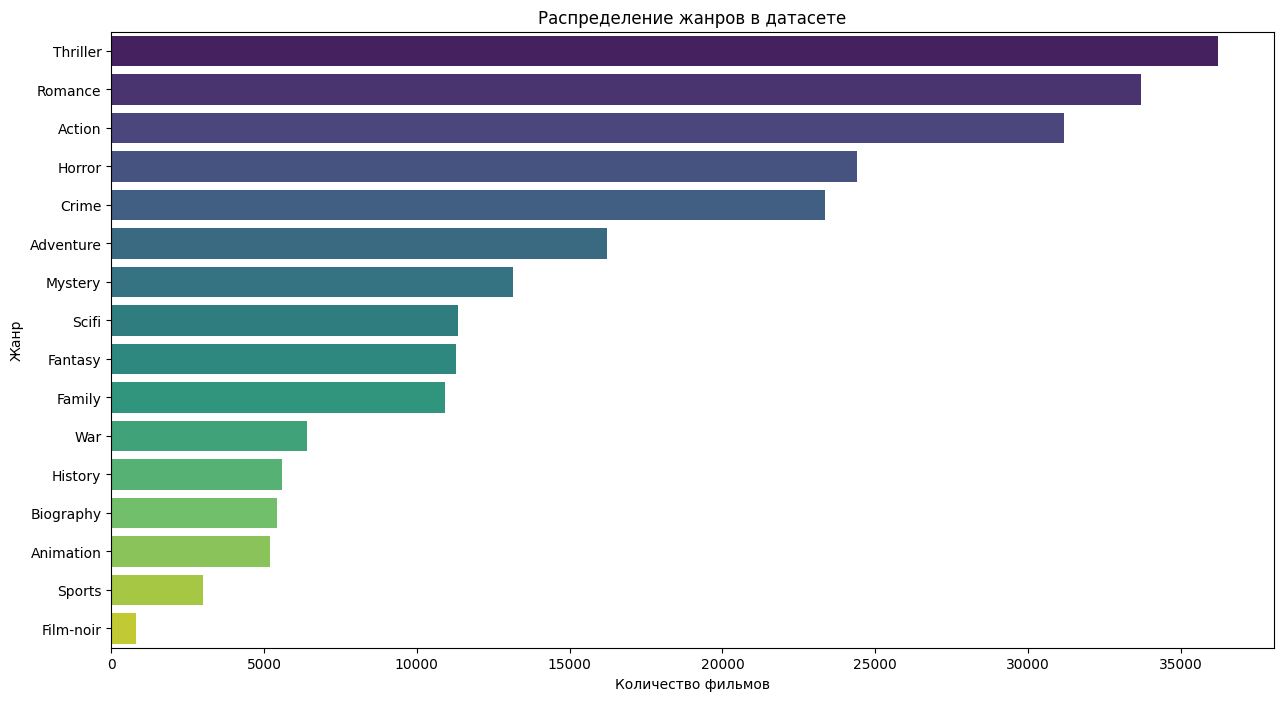

In [3]:
plt.figure(figsize=(15, 8))
sns.countplot(y='genre', data=train_df, order=train_df['genre'].value_counts().index, palette='viridis')
plt.title("Распределение жанров в датасете")
plt.xlabel("Количество фильмов")
plt.ylabel("Жанр")
plt.show()

### 📏 Анализ длины описаний сюжетов
Проверим количество слов в описаниях.

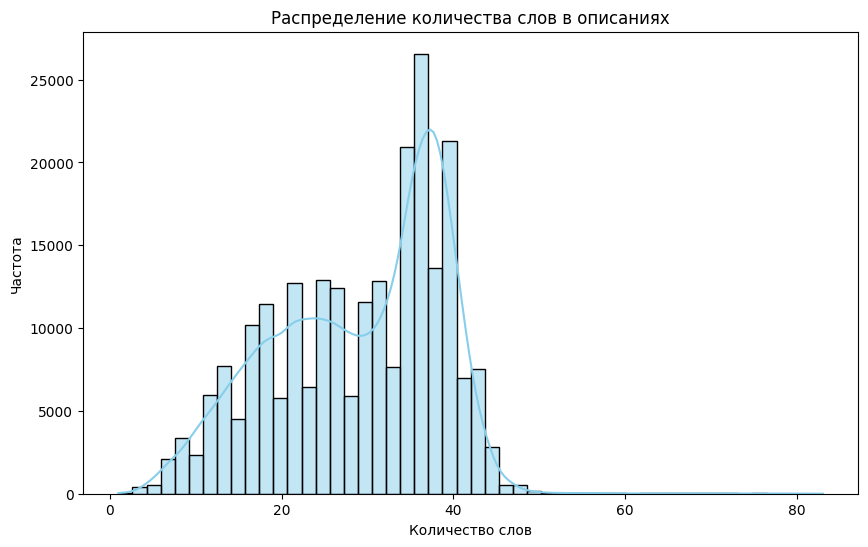

In [4]:
train_df['plot_len'] = train_df['description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(train_df['plot_len'], bins=50, color='skyblue', kde=True)
plt.title("Распределение количества слов в описаниях")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

## 3. Токенизация и Препроцессинг

Подготовим данные для модели **DistilBERT**. Для классификации нам нужно преобразовать строковые названия жанров в числовые метки.

In [ ]:
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['genre'])
label_names = label_encoder.classes_

def tokenize_data(batch):
    tokenized = tokenizer(batch["description"], padding=True, truncation=True)
    tokenized["labels"] = label_encoder.transform(batch["genre"])
    return tokenized

dataset_encoded = dataset.map(tokenize_data, batched=True, batch_size=None)

print(f"Метки жанров: {list(enumerate(label_names))}")

Метки жанров: [(0, 'Action'), (1, 'Adventure'), (2, 'Animation'), (3, 'Biography'), (4, 'Crime'), (5, 'Family'), (6, 'Fantasy'), (7, 'Film-noir'), (8, 'History'), (9, 'Horror'), (10, 'Mystery'), (11, 'Romance'), (12, 'Scifi'), (13, 'Sports'), (14, 'Thriller'), (15, 'War')]


: 

## 4. Обучение модели (Fine-Tuning)

Дообучим DistilBERT классифицировать сюжеты по жанрам. Для ускорения демонстрации возьмем подвыборку данных.

In [ ]:
num_labels = len(label_names)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

train_subset = dataset_encoded["train"].shuffle(seed=42).select(range(3000))

test_subset = dataset_encoded["train"].shuffle(seed=42).select(range(3000, 4000))

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_subset,
    eval_dataset=test_subset,
    processing_class=tokenizer
)

print("🚀 Начинаем дообучение на жанрах фильмов...")
trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 529.97it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Начинаем дообучение на жанрах фильмов...


c:\Users\rakhm\anaconda3\envs\ml-iris\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.550468,2.239645,0.266000,0.208421
2,2.097106,2.091753,0.304000,0.258298


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s]
c:\Users\rakhm\anaconda3\envs\ml-iris\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]
c:\Users\rakhm\anaconda3\envs\ml-iris\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 5. Оценка результатов

Построим матрицу ошибок, чтобы увидеть, какие жанры модель различает лучше всего.

In [ ]:
preds_output = trainer.predict(test_subset)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = test_subset["labels"]

cm = confusion_matrix(y_true, y_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Матрица ошибок (Классификация жанров)")
plt.show()

## 6. Сохранение и Тестирование

Сохраняем модель и токенизатор для использования в боте.

In [ ]:
import os
save_path = "../models/genre_classifier"
if not os.path.exists(save_path):
    os.makedirs(save_path)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
import pickle
with open(os.path.join(save_path, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

print(f"✅ Модель и энкодер меток сохранены в {save_path}")

In [ ]:
def predict_genre(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    
    pred_idx = torch.argmax(logits, dim=1).item()
    return label_names[pred_idx]

test_text = "A young wizard discovers his magical heritage and attends a school for magic while fighting an evil dark lord."
print(f"Текст: {test_text}")
print(f"Предсказанный жанр: {predict_genre(test_text)}")